In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [2]:
test = pd.read_csv('/kaggle/input/ai-mathematical-olympiad-prize/test.csv')
test.head()

,row_id,id,problem
0,0,000aaa,What is $1-1$?
1,1,111bbb,What is $0\times10$?
2,2,222ccc,Solve $4+x=4$ for $x$.


In [3]:
train = pd.read_csv('/kaggle/input/ai-mathematical-olympiad-prize/train.csv')
train.head()

,id,problem,answer
0,229ee8,"Let $k, l > 0$ be parameters. The parabola $y ...",52
1,246d26,Each of the three-digits numbers $111$ to $999...,250
2,2fc4ad,Let the `sparkle' operation on positive intege...,702
3,430b63,What is the minimum value of $5x^2+5y^2-8xy$ w...,800
4,5277ed,There exists a unique increasing geometric seq...,211


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,problem,answer,row_id
0,229ee8,"Let $k, l > 0$ be parameters. The parabola $y ...",52.0,NaN
1,246d26,Each of the three-digits numbers $111$ to $999...,250.0,NaN
2,2fc4ad,Let the `sparkle' operation on positive intege...,702.0,NaN
3,430b63,What is the minimum value of $5x^2+5y^2-8xy$ w...,800.0,NaN
4,5277ed,There exists a unique increasing geometric seq...,211.0,NaN


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 0 to 2
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       13 non-null     object 
 1   problem  13 non-null     object 
 2   answer   10 non-null     float64
 3   row_id   3 non-null      float64
dtypes: float64(2), object(2)
memory usage: 520.0+ bytes


In [6]:
combined.dtypes

id          object
problem     object
answer     float64
row_id     float64
dtype: object

In [7]:
combined.corr

<bound method DataFrame.corr of        id                                            problem  answer  row_id
0  229ee8  Let $k, l > 0$ be parameters. The parabola $y ...    52.0     NaN
1  246d26  Each of the three-digits numbers $111$ to $999...   250.0     NaN
2  2fc4ad  Let the `sparkle' operation on positive intege...   702.0     NaN
3  430b63  What is the minimum value of $5x^2+5y^2-8xy$ w...   800.0     NaN
4  5277ed  There exists a unique increasing geometric seq...   211.0     NaN
5  739bc9  For how many positive integers $m$ does the eq...   199.0     NaN
6  82e2a0  Suppose that we roll four 6-sided fair dice wi...   185.0     NaN
7  8ee6f3  The points $\left(x, y\right)$ satisfying $((\...   320.0     NaN
8  bedda4  Let $ABCD$ be a unit square. Let $P$ be the po...   480.0     NaN
9  d7e9c9  A function $f: \mathbb N \to \mathbb N$ satisf...   199.0     NaN
0  000aaa                                     What is $1-1$?     NaN     0.0
1  111bbb                               What

In [8]:
combined.columns

Index(['id', 'problem', 'answer', 'row_id'], dtype='object')

In [9]:
combined.shape

(13, 4)

In [10]:
combined.isnull().sum()/len('combined')*100

id           0.0
problem      0.0
answer      37.5
row_id     125.0
dtype: float64

In [11]:
combined.kurt

<bound method DataFrame.kurt of        id                                            problem  answer  row_id
0  229ee8  Let $k, l > 0$ be parameters. The parabola $y ...    52.0     NaN
1  246d26  Each of the three-digits numbers $111$ to $999...   250.0     NaN
2  2fc4ad  Let the `sparkle' operation on positive intege...   702.0     NaN
3  430b63  What is the minimum value of $5x^2+5y^2-8xy$ w...   800.0     NaN
4  5277ed  There exists a unique increasing geometric seq...   211.0     NaN
5  739bc9  For how many positive integers $m$ does the eq...   199.0     NaN
6  82e2a0  Suppose that we roll four 6-sided fair dice wi...   185.0     NaN
7  8ee6f3  The points $\left(x, y\right)$ satisfying $((\...   320.0     NaN
8  bedda4  Let $ABCD$ be a unit square. Let $P$ be the po...   480.0     NaN
9  d7e9c9  A function $f: \mathbb N \to \mathbb N$ satisf...   199.0     NaN
0  000aaa                                     What is $1-1$?     NaN     0.0
1  111bbb                               What

In [12]:
combined.skew

<bound method DataFrame.skew of        id                                            problem  answer  row_id
0  229ee8  Let $k, l > 0$ be parameters. The parabola $y ...    52.0     NaN
1  246d26  Each of the three-digits numbers $111$ to $999...   250.0     NaN
2  2fc4ad  Let the `sparkle' operation on positive intege...   702.0     NaN
3  430b63  What is the minimum value of $5x^2+5y^2-8xy$ w...   800.0     NaN
4  5277ed  There exists a unique increasing geometric seq...   211.0     NaN
5  739bc9  For how many positive integers $m$ does the eq...   199.0     NaN
6  82e2a0  Suppose that we roll four 6-sided fair dice wi...   185.0     NaN
7  8ee6f3  The points $\left(x, y\right)$ satisfying $((\...   320.0     NaN
8  bedda4  Let $ABCD$ be a unit square. Let $P$ be the po...   480.0     NaN
9  d7e9c9  A function $f: \mathbb N \to \mathbb N$ satisf...   199.0     NaN
0  000aaa                                     What is $1-1$?     NaN     0.0
1  111bbb                               What

<Axes: >

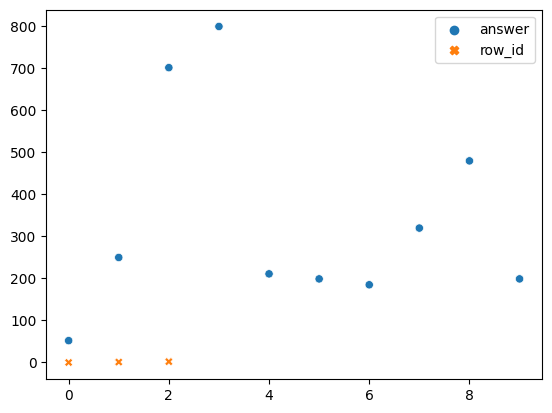

In [13]:
sns.scatterplot(combined)

<Axes: >

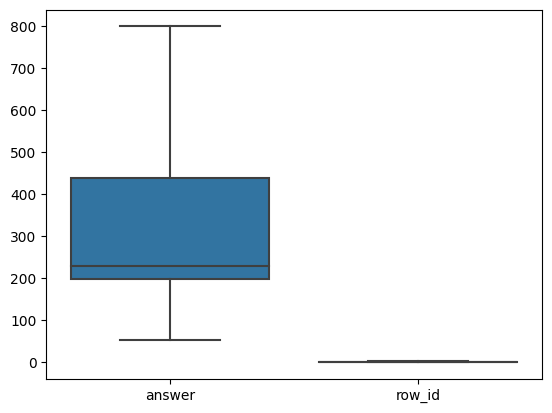

In [14]:
sns.boxplot(combined)

<Axes: >

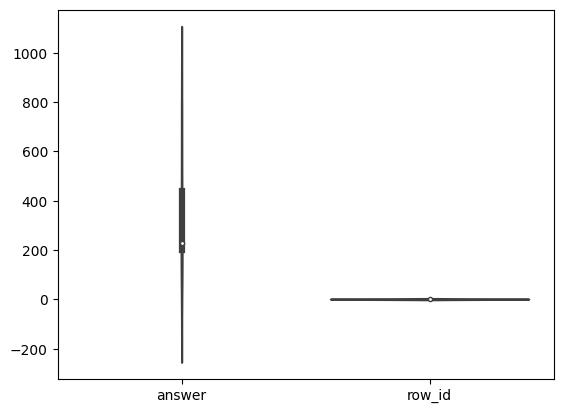

In [15]:
sns.violinplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

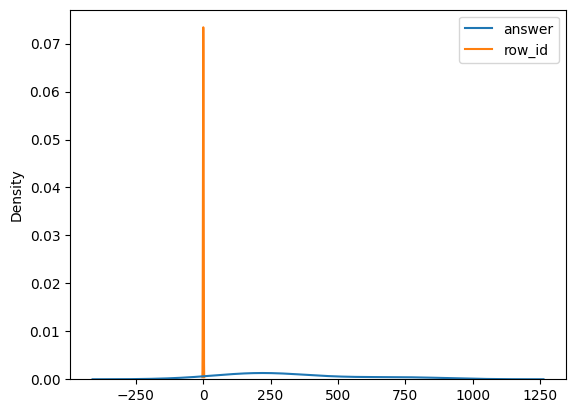

In [16]:
sns.kdeplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


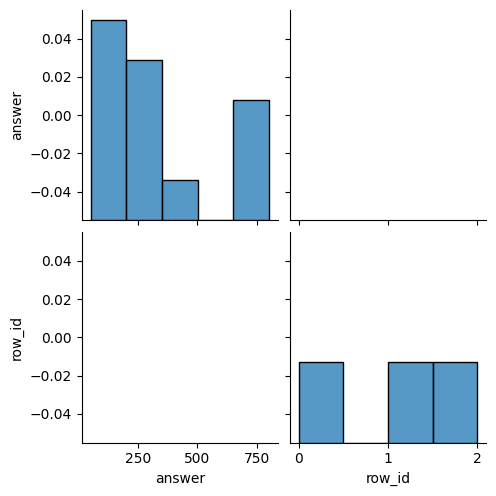

In [17]:
sns.pairplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

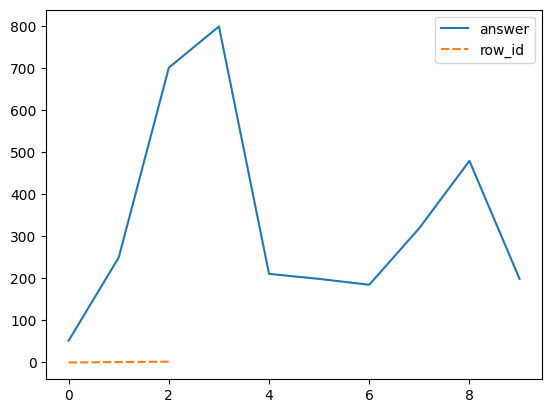

In [18]:
sns.lineplot(combined)

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


<Axes: >

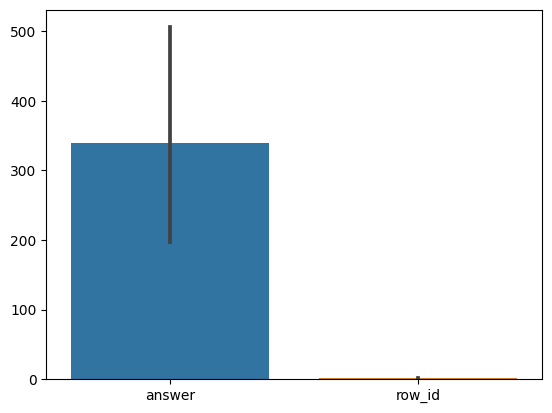

In [19]:
sns.barplot(combined)

In [5]:
cat_cols = combined.select_dtypes(include='object')

In [6]:
for i in cat_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*100)

id
____________________________________________________________________________________________________
problem
____________________________________________________________________________________________________


In [7]:
num_cols = combined.select_dtypes(include='number')

In [8]:
for i in num_cols:
    print(i)
    (combined[i].value_counts())
    print('_'*50)

answer
__________________________________________________
row_id
__________________________________________________


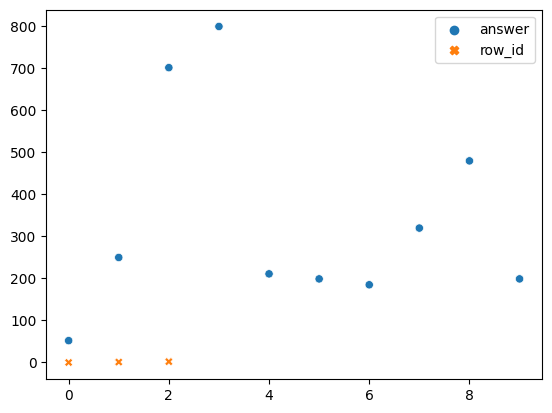

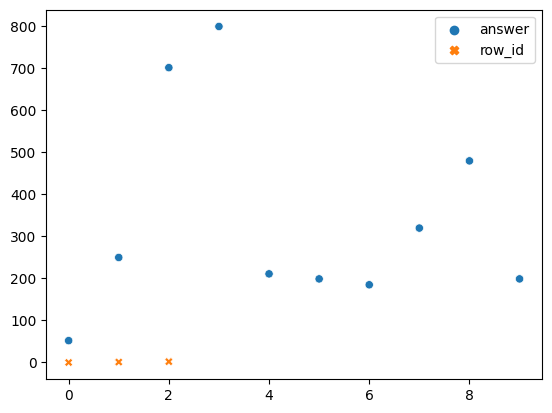

In [25]:
x = 1
cat_cols = combined.select_dtypes(include='object')
for i in cat_cols:
    sns.scatterplot(data=combined)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


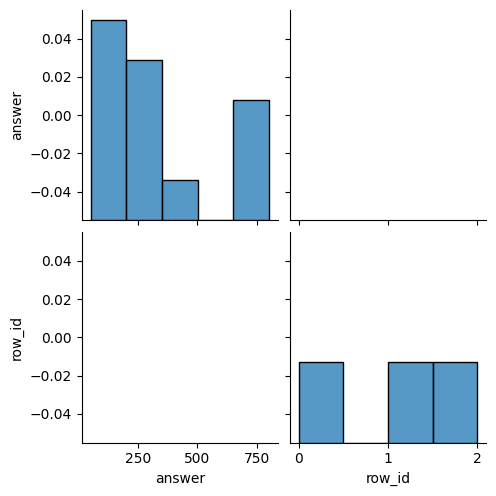

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


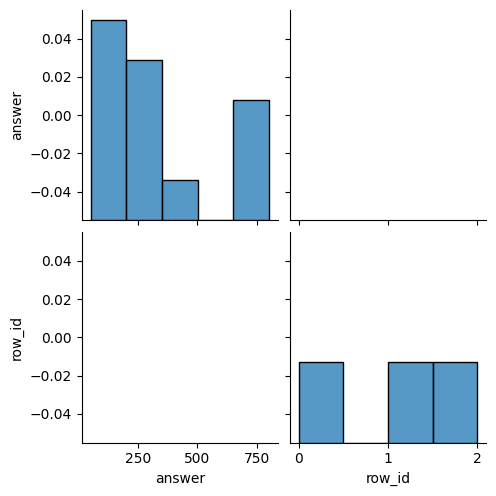

In [26]:
x=1
num_cols = combined.select_dtypes(include='number')
for i in num_cols:
    sns.pairplot(data=combined)
    print('\n')
    plt.show()
    

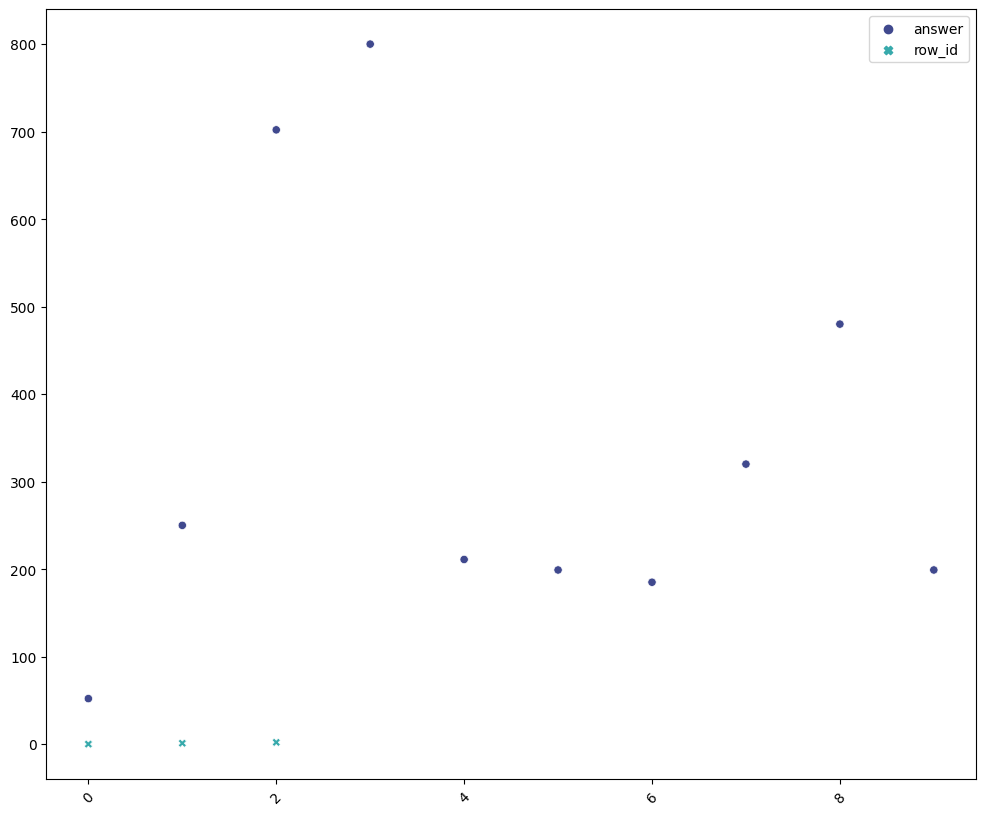

In [27]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=combined,palette='mako');
plt.xticks(rotation=45);
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

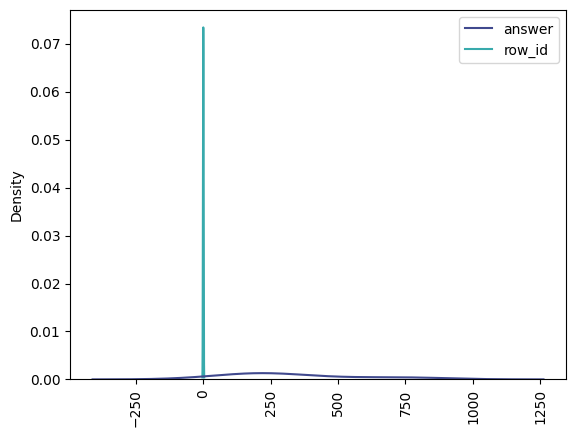

In [28]:
sns.kdeplot(data=combined,palette='mako');
plt.xticks(rotation=90)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))


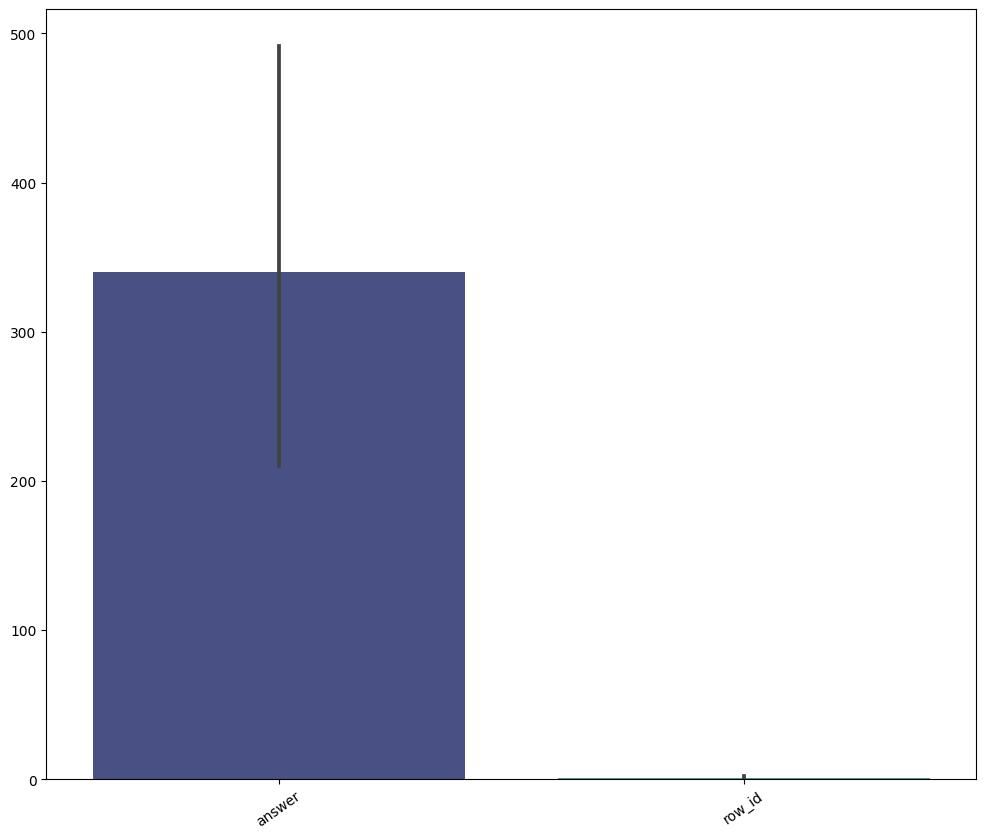

In [29]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=35);
plt.show()

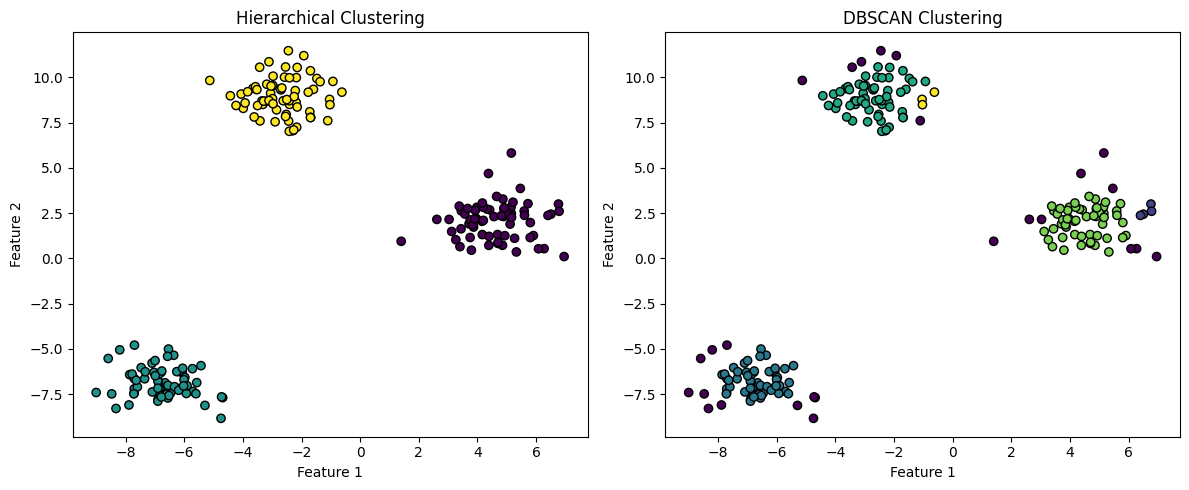

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, DBSCAN

x,_ = make_blobs(n_samples=200, centers=3, random_state=42)

agg_clustering = AgglomerativeClustering(n_clusters=3)
agg_clusters = agg_clustering.fit_predict(x)

dbscan = DBSCAN(eps=0.6, min_samples=3)
dbscan_cluster = dbscan.fit_predict(x)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(x[:,0], x[:,1], c=agg_clusters, cmap='viridis',edgecolors='k')
plt.title('Hierarchical Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1,2,2)
plt.scatter(x[:,0],x[:,1], c=dbscan_cluster, cmap='viridis',edgecolors='k')
plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()


In [14]:
x = combined[['id']]

In [15]:
y = combined[['answer']]

In [16]:
from sklearn.model_selection import train_test_split


In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [18]:
from sklearn.linear_model import  LinearRegression

In [19]:
lr = LinearRegression()

In [22]:
from sklearn.metrics import mean_squared_error